In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rishikeshkonapure/home-loan-approval")

print("Path to dataset files:", path)

100%|██████████| 12.6k/12.6k [00:00<00:00, 9.99MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rishikeshkonapure/home-loan-approval/versions/1


In [ ]:
import os
print(os.listdir(path))

['loan_sanction_test.csv', 'loan_sanction_train.csv']


##EDA

In [ ]:
df=pd.read_csv(path+'/loan_sanction_train.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df.dropna(inplace=True)

##Visualize

<Axes: xlabel='ApplicantIncome'>

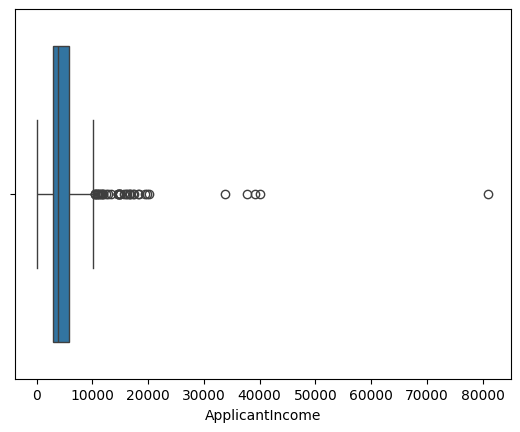

In [ ]:
sns.boxplot(x=df['ApplicantIncome'])

<Axes: xlabel='ApplicantIncome', ylabel='Count'>

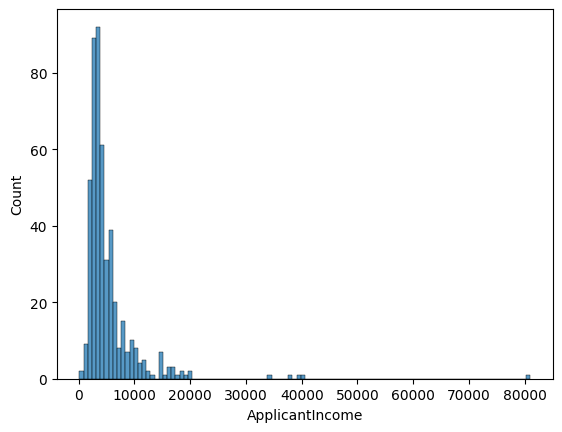

In [ ]:
sns.histplot(x=df['ApplicantIncome'])

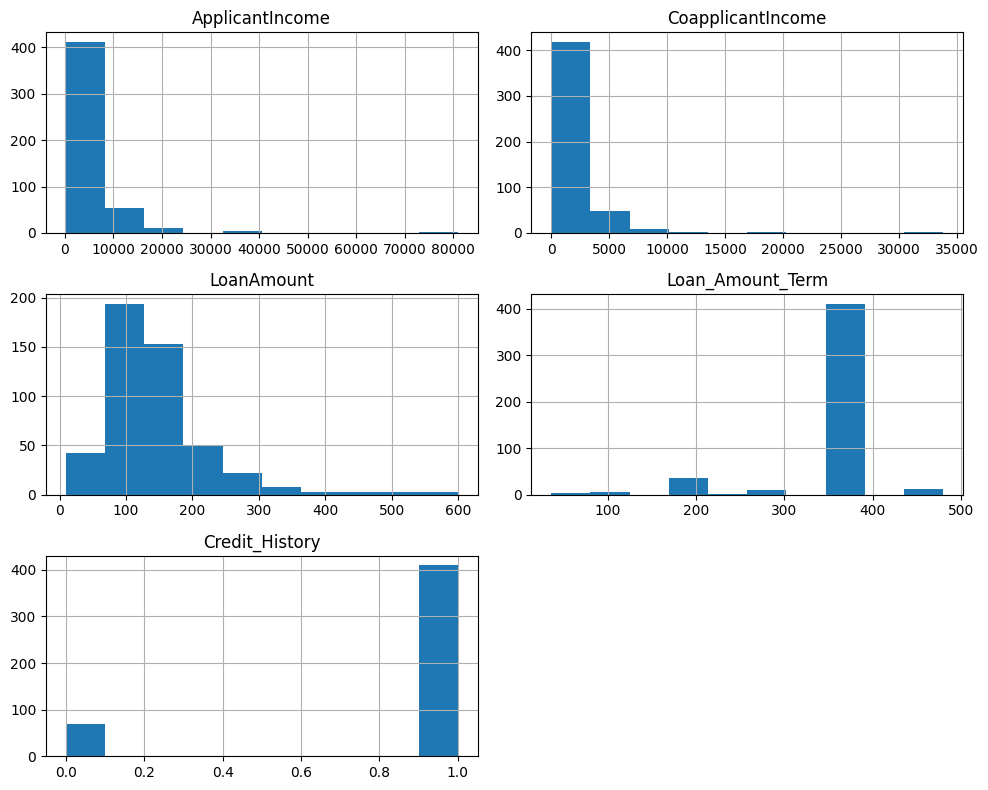

In [ ]:
df.hist(figsize=(10,8))
plt.tight_layout()## IT prints all

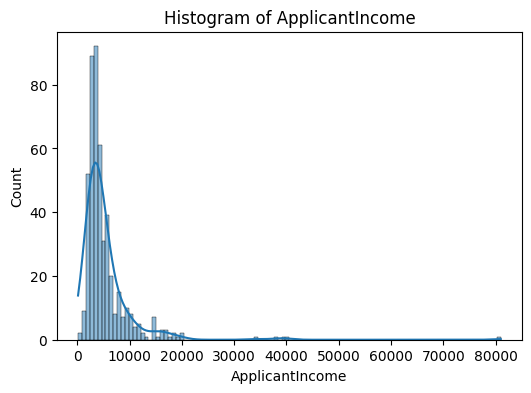

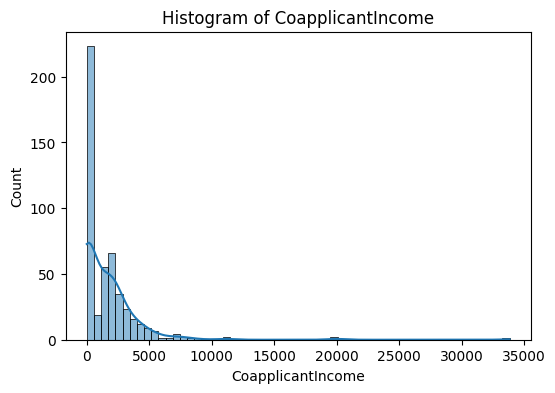

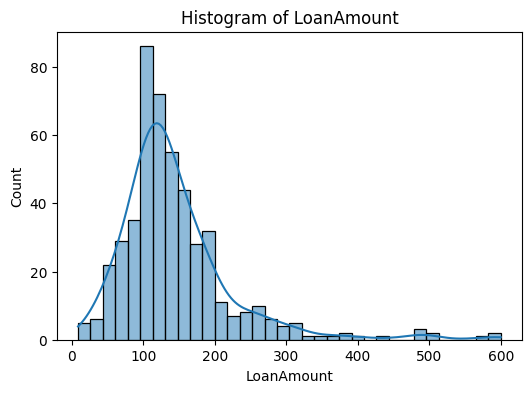

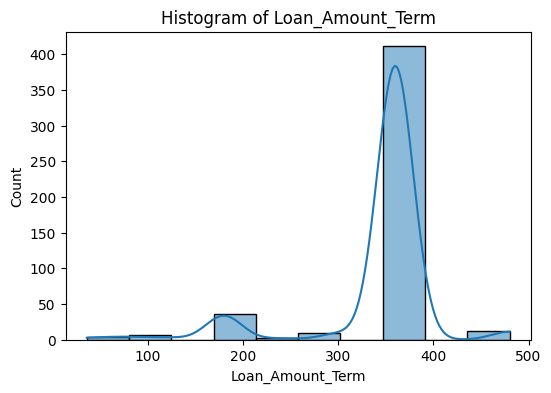

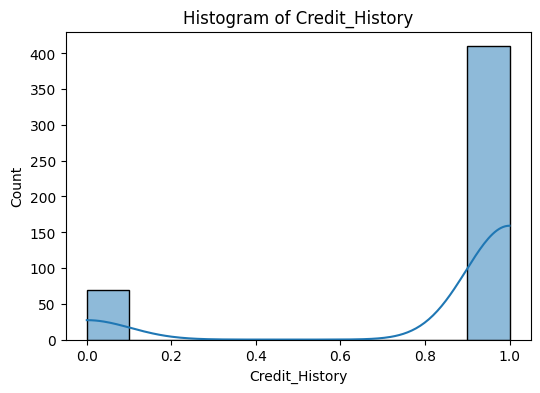

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

<Axes: >

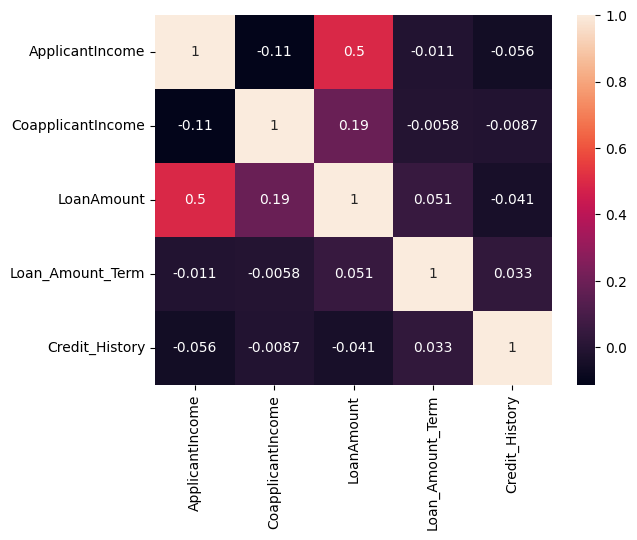

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
corr=df.corr(numeric_only=True)['ApplicantIncome']
print(corr.sort_values(ascending=False))

ApplicantIncome      1.000000
LoanAmount           0.495310
Loan_Amount_Term    -0.010838
Credit_History      -0.056152
CoapplicantIncome   -0.112588
Name: ApplicantIncome, dtype: float64


##Encode

In [ ]:
df = df.drop('Loan_ID', axis=1)

In [ ]:
encode=pd.get_dummies(data=df,drop_first=True)
encode.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
1,4583,1508.0,128.0,360.0,1.0,True,True,True,False,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,True,True,False,False,False,False,True,False,True,True
3,2583,2358.0,120.0,360.0,1.0,True,True,False,False,False,True,False,False,True,True
4,6000,0.0,141.0,360.0,1.0,True,False,False,False,False,False,False,False,True,True
5,5417,4196.0,267.0,360.0,1.0,True,True,False,True,False,False,True,False,True,True


In [ ]:
encode.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Gender_Male', 'Married_Yes',
       'Dependents_1', 'Dependents_2', 'Dependents_3+',
       'Education_Not Graduate', 'Self_Employed_Yes',
       'Property_Area_Semiurban', 'Property_Area_Urban', 'Loan_Status_Y'],
      dtype='object')

## Select X and Y

In [ ]:
X=encode.drop('Loan_Status_Y',axis=1)

In [ ]:
y=encode['Loan_Status_Y']

##Train Test split

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=64)

##Train Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

##Confusion,accuracy

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score
y_pred=model.predict(X_test)
cm=confusion_matrix(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)
print(f"Confusion Matrix : \n{cm}\nAccuracy Score = {accuracy}")

Confusion Matrix : 
[[14 12]
 [12 58]]
Accuracy Score = 0.75


##Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

       False       0.54      0.54      0.54        26
        True       0.83      0.83      0.83        70

    accuracy                           0.75        96
   macro avg       0.68      0.68      0.68        96
weighted avg       0.75      0.75      0.75        96



##Visualize Tree

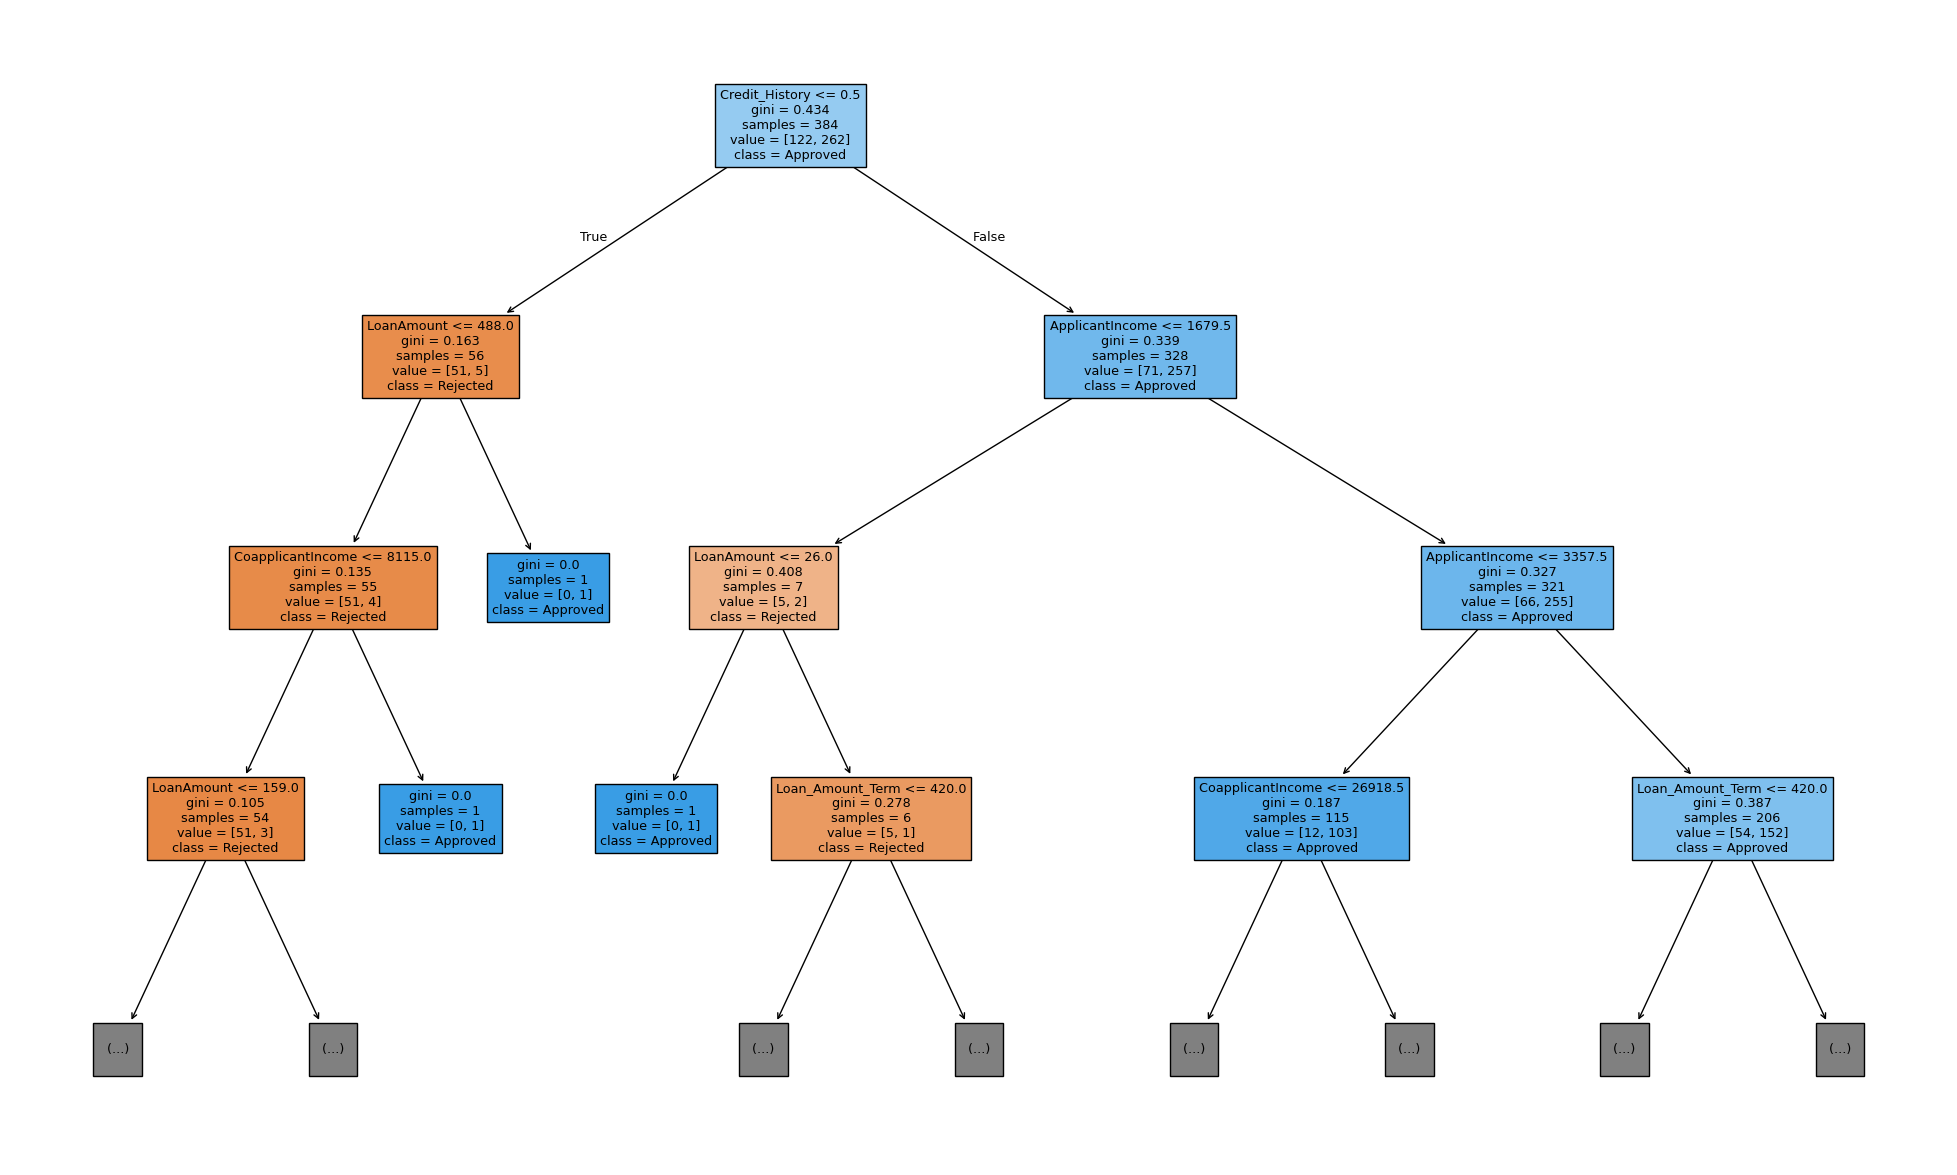

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(25,15))
plot_tree(
    model,
    max_depth=3,
    filled=True,
    feature_names=X.columns,
    class_names=['Rejected','Approved']
)

plt.show()

In [ ]:
X.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Gender_Male', 'Married_Yes',
       'Dependents_1', 'Dependents_2', 'Dependents_3+',
       'Education_Not Graduate', 'Self_Employed_Yes',
       'Property_Area_Semiurban', 'Property_Area_Urban'],
      dtype='object')

In [ ]:
new_data = [[
    5000,   # ApplicantIncome
    2000,   # CoapplicantIncome
    150,    # LoanAmount
    360,    # Loan_Amount_Term
    1       # Credit_History
]]

In [ ]:
print(len(X.columns))

14


In [ ]:
print(X.columns.tolist())

['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Gender_Male', 'Married_Yes', 'Dependents_1', 'Dependents_2', 'Dependents_3+', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']


##Decision

In [ ]:
new_data = [[
    5000,  # ApplicantIncome
    2000,  # CoapplicantIncome
    150,   # LoanAmount
    360,   # Loan_Amount_Term
    1,     # Credit_History

    1,     # Gender_Male
    1,     # Married_Yes

    1,     # Dependents_1
    0,     # Dependents_2
    0,     # Dependents_3+

    0,     # Education_Not Graduate

    0,     # Self_Employed_Yes

    0,     # Property_Area_Semiurban
    1      # Property_Area_Urban
]]

prediction = model.predict(new_data)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Approved
